In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

          x         y  target
0  9.833469  0.319565       0
1  1.801045  8.705072       0
2  4.423918  3.488906       1
3  0.280730  2.689037       1
4  5.999494  9.167512       0


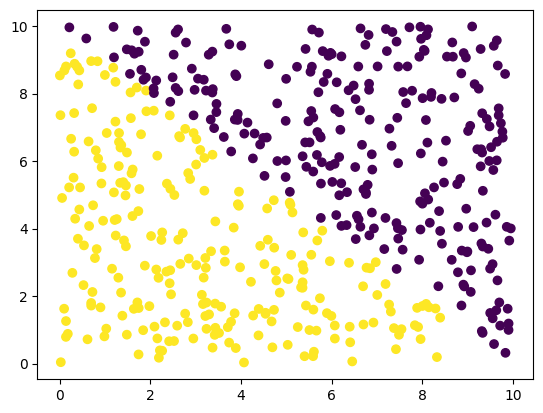

In [2]:
file_path = os.path.join('..','Datasets','sintetico_2d.csv')

df = pd.read_csv(file_path)

print(df.head(5))

plt.scatter(df['x'], df['y'], c=df['target'])

plt.show()

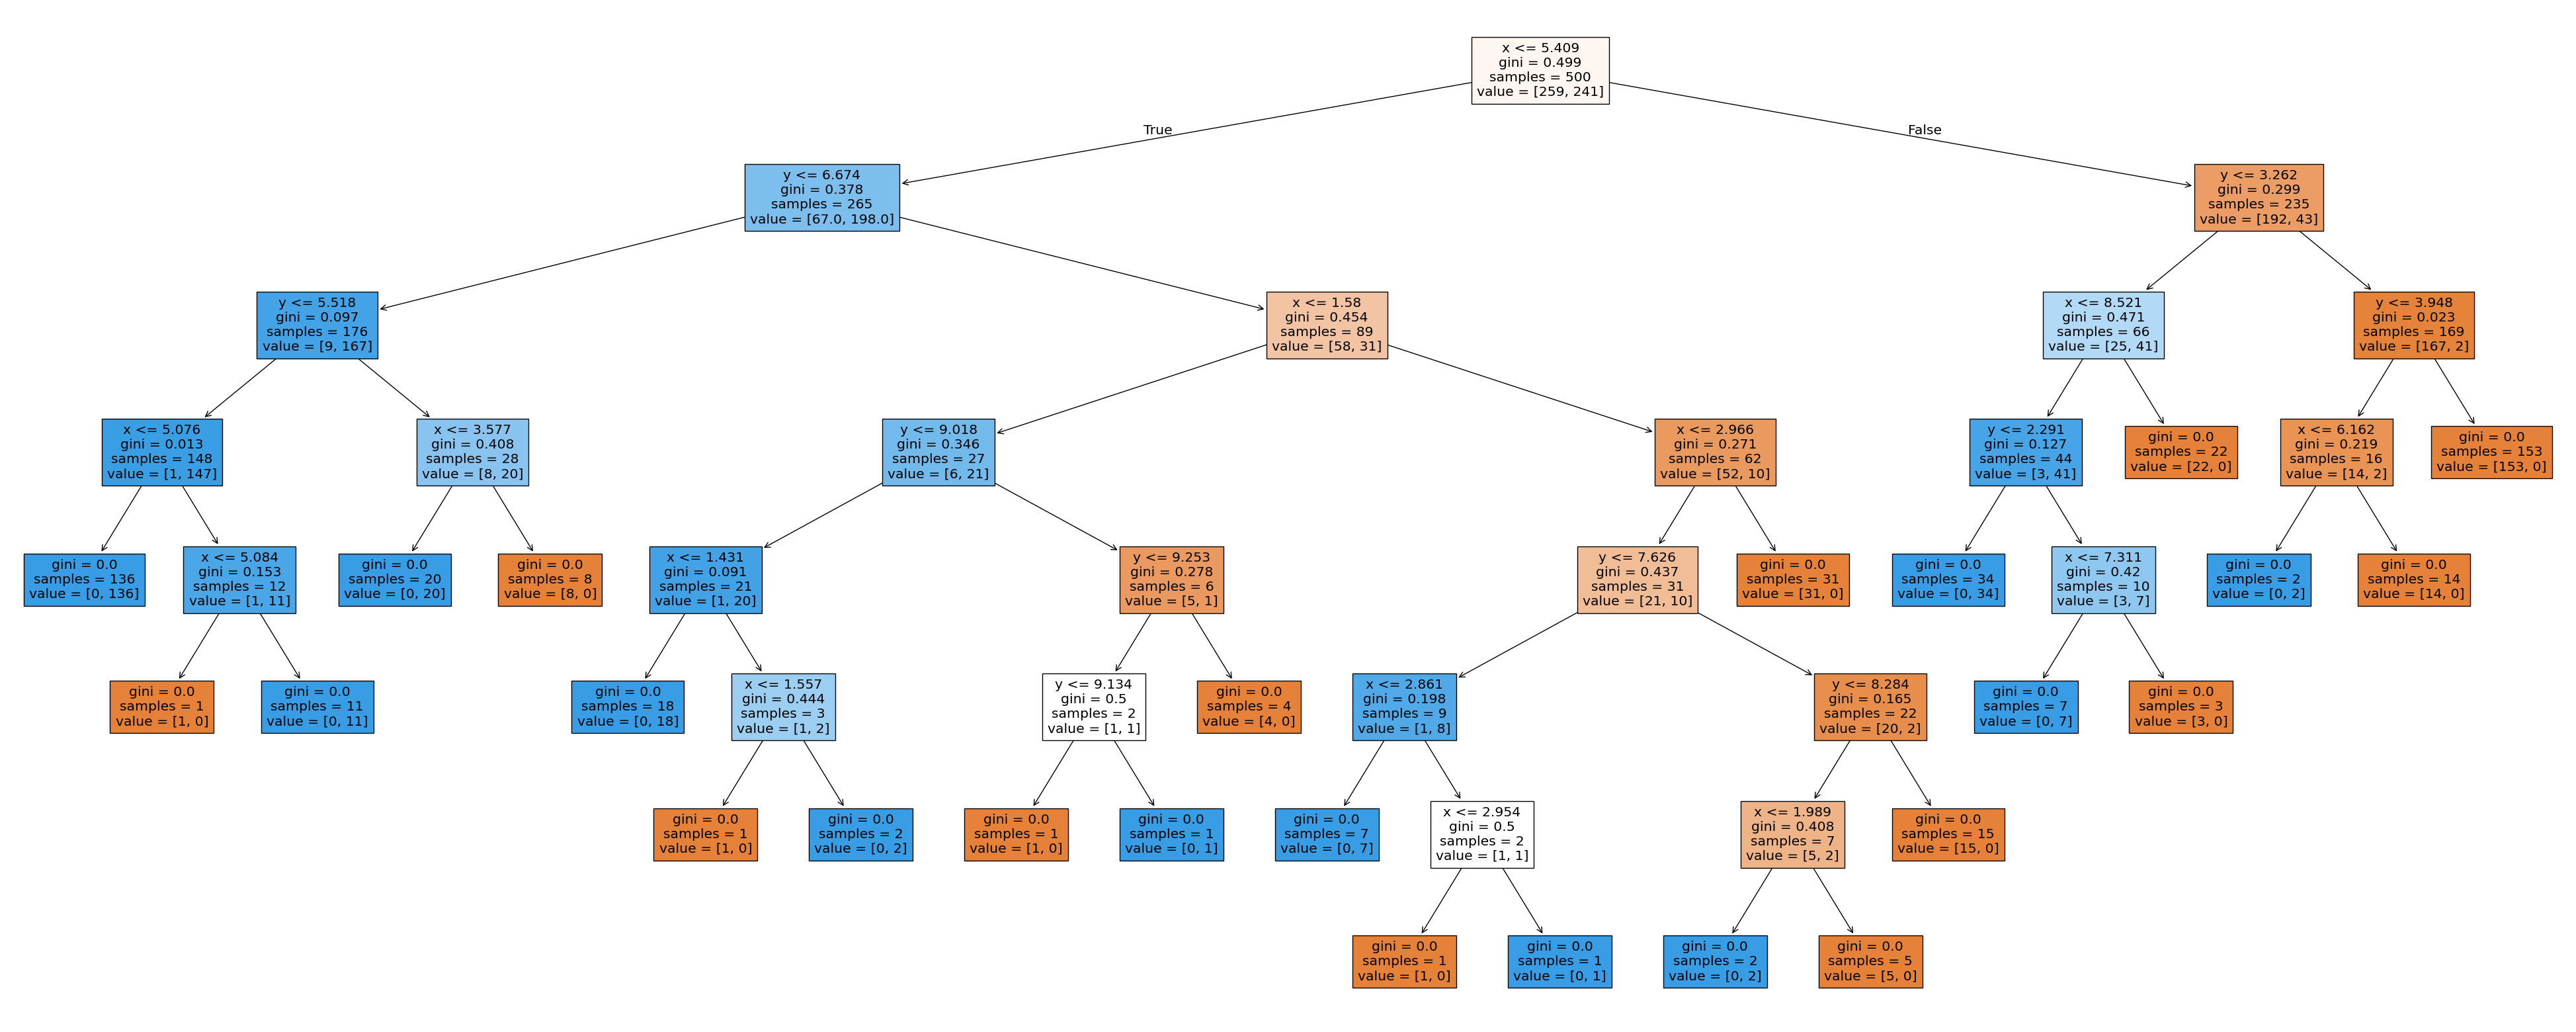

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.values[:,:2]
y = df.values[:,2]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

clf = DecisionTreeClassifier()

clf.fit(X,y)

plt.figure(figsize=(50, 20))
plot_tree(clf, feature_names=df.columns, filled=True)
plt.show()

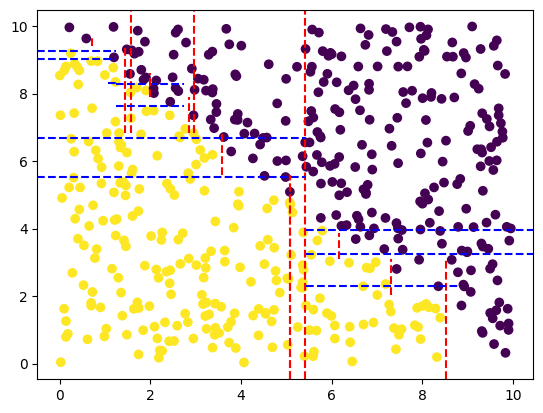

In [4]:
from dibujar_divisiones import dibujar_divisiones

dibujar_divisiones(clf.tree_.feature, clf.tree_.threshold, 0, 0, 10, 0, 10)
plt.scatter(df['x'], df['y'], c=df['target'])
plt.show()

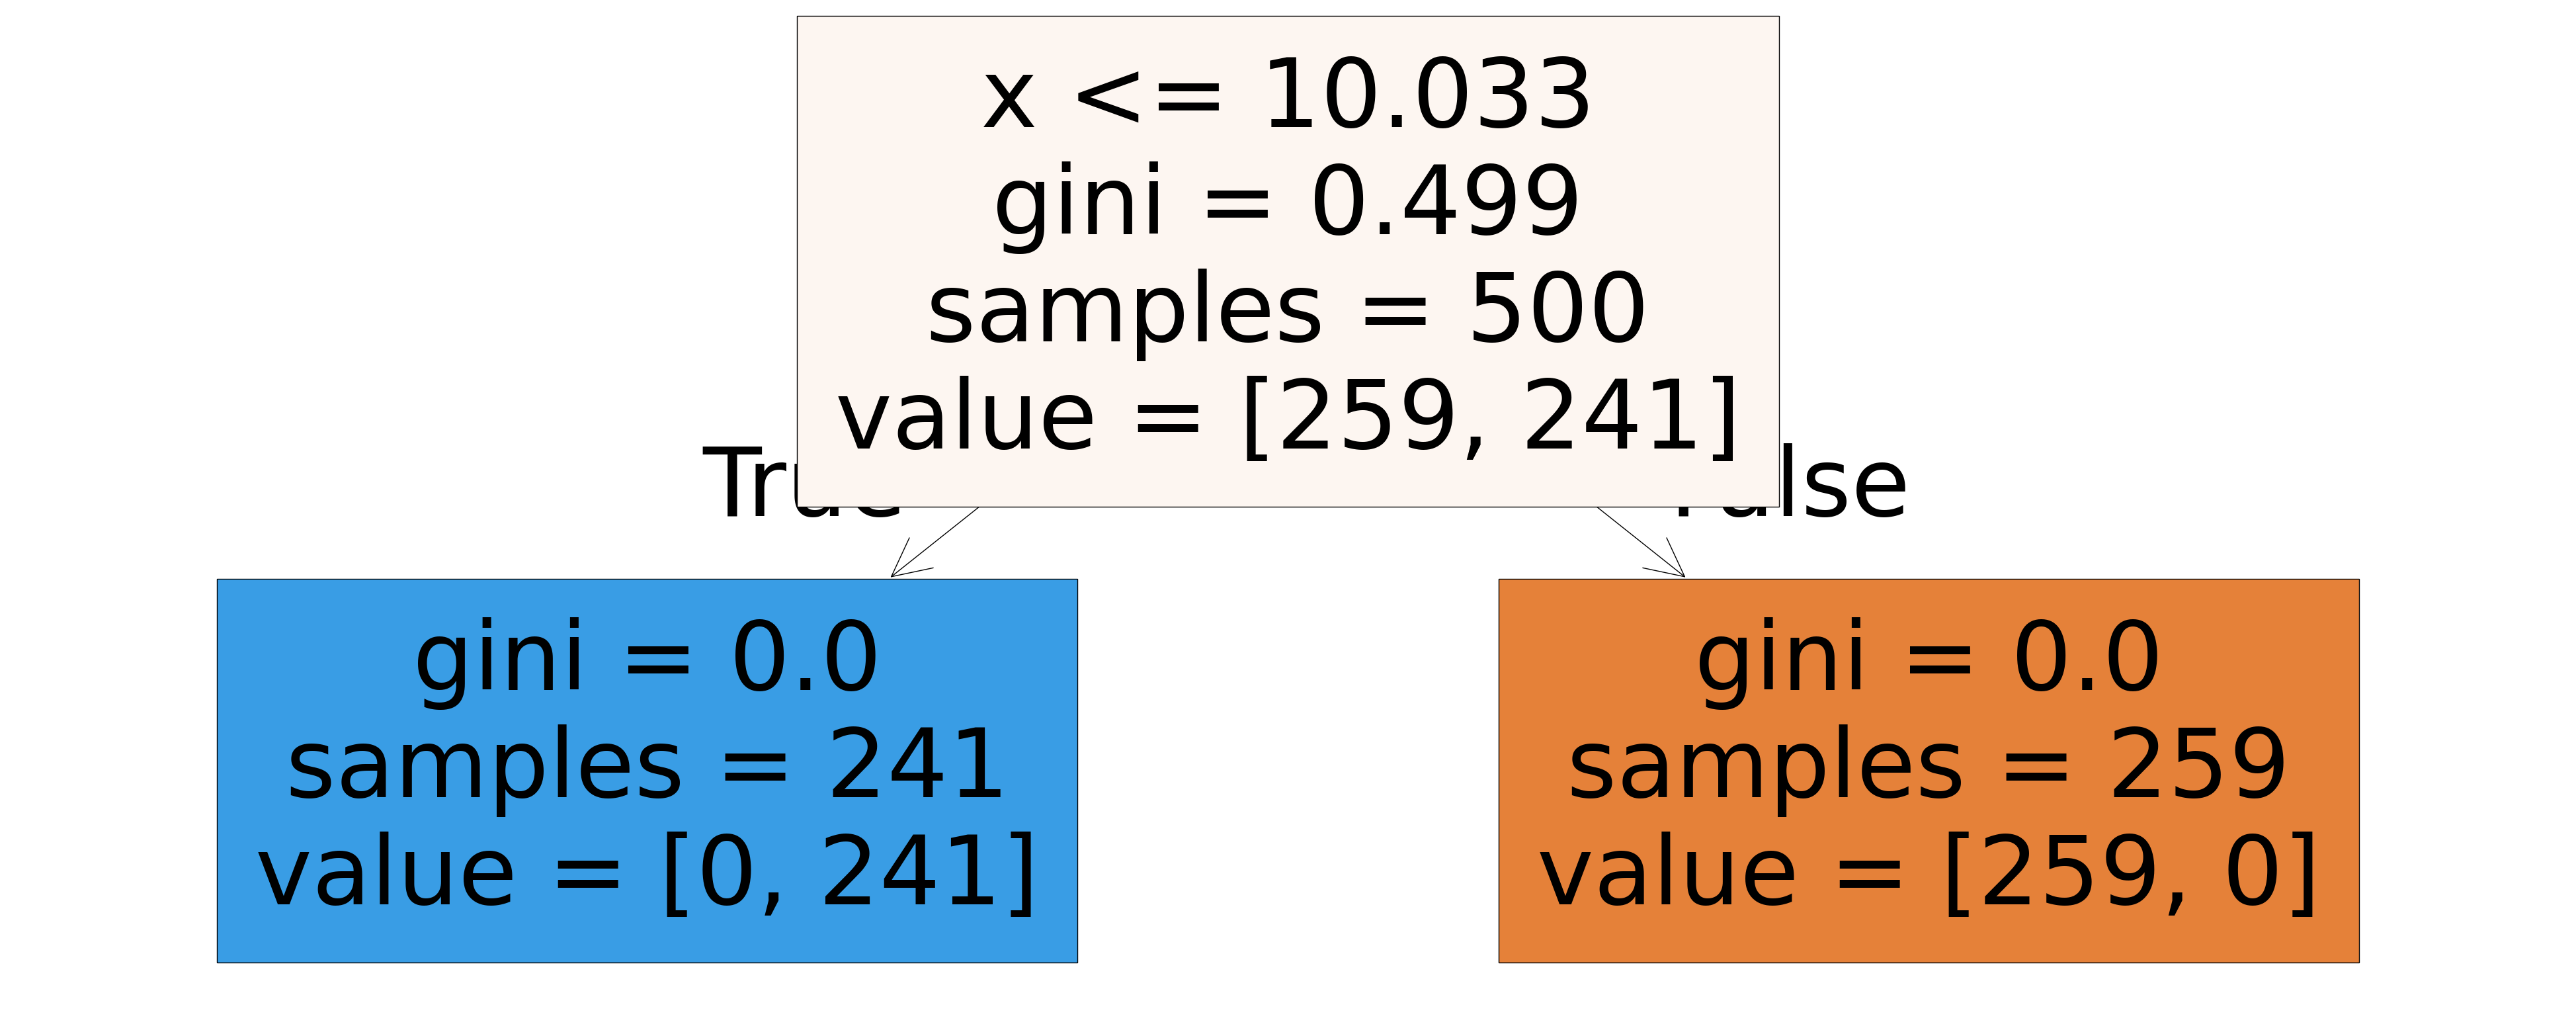

In [5]:
X_nuevo = (X[:,0] + X[:,1]).reshape(500,1)

clf = DecisionTreeClassifier()

clf.fit(X_nuevo,y)

plt.figure(figsize=(50, 20))
plot_tree(clf, feature_names=df.columns, filled=True)
plt.show()

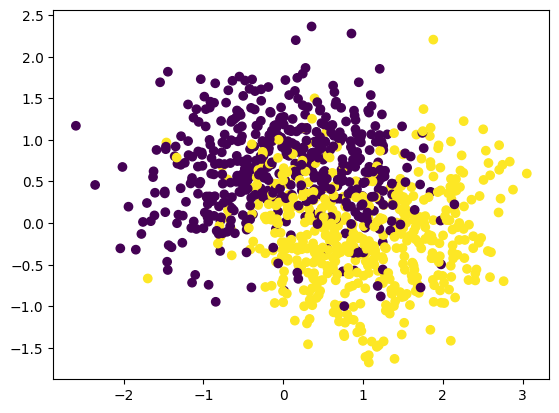

In [47]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.5, random_state=123)

plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

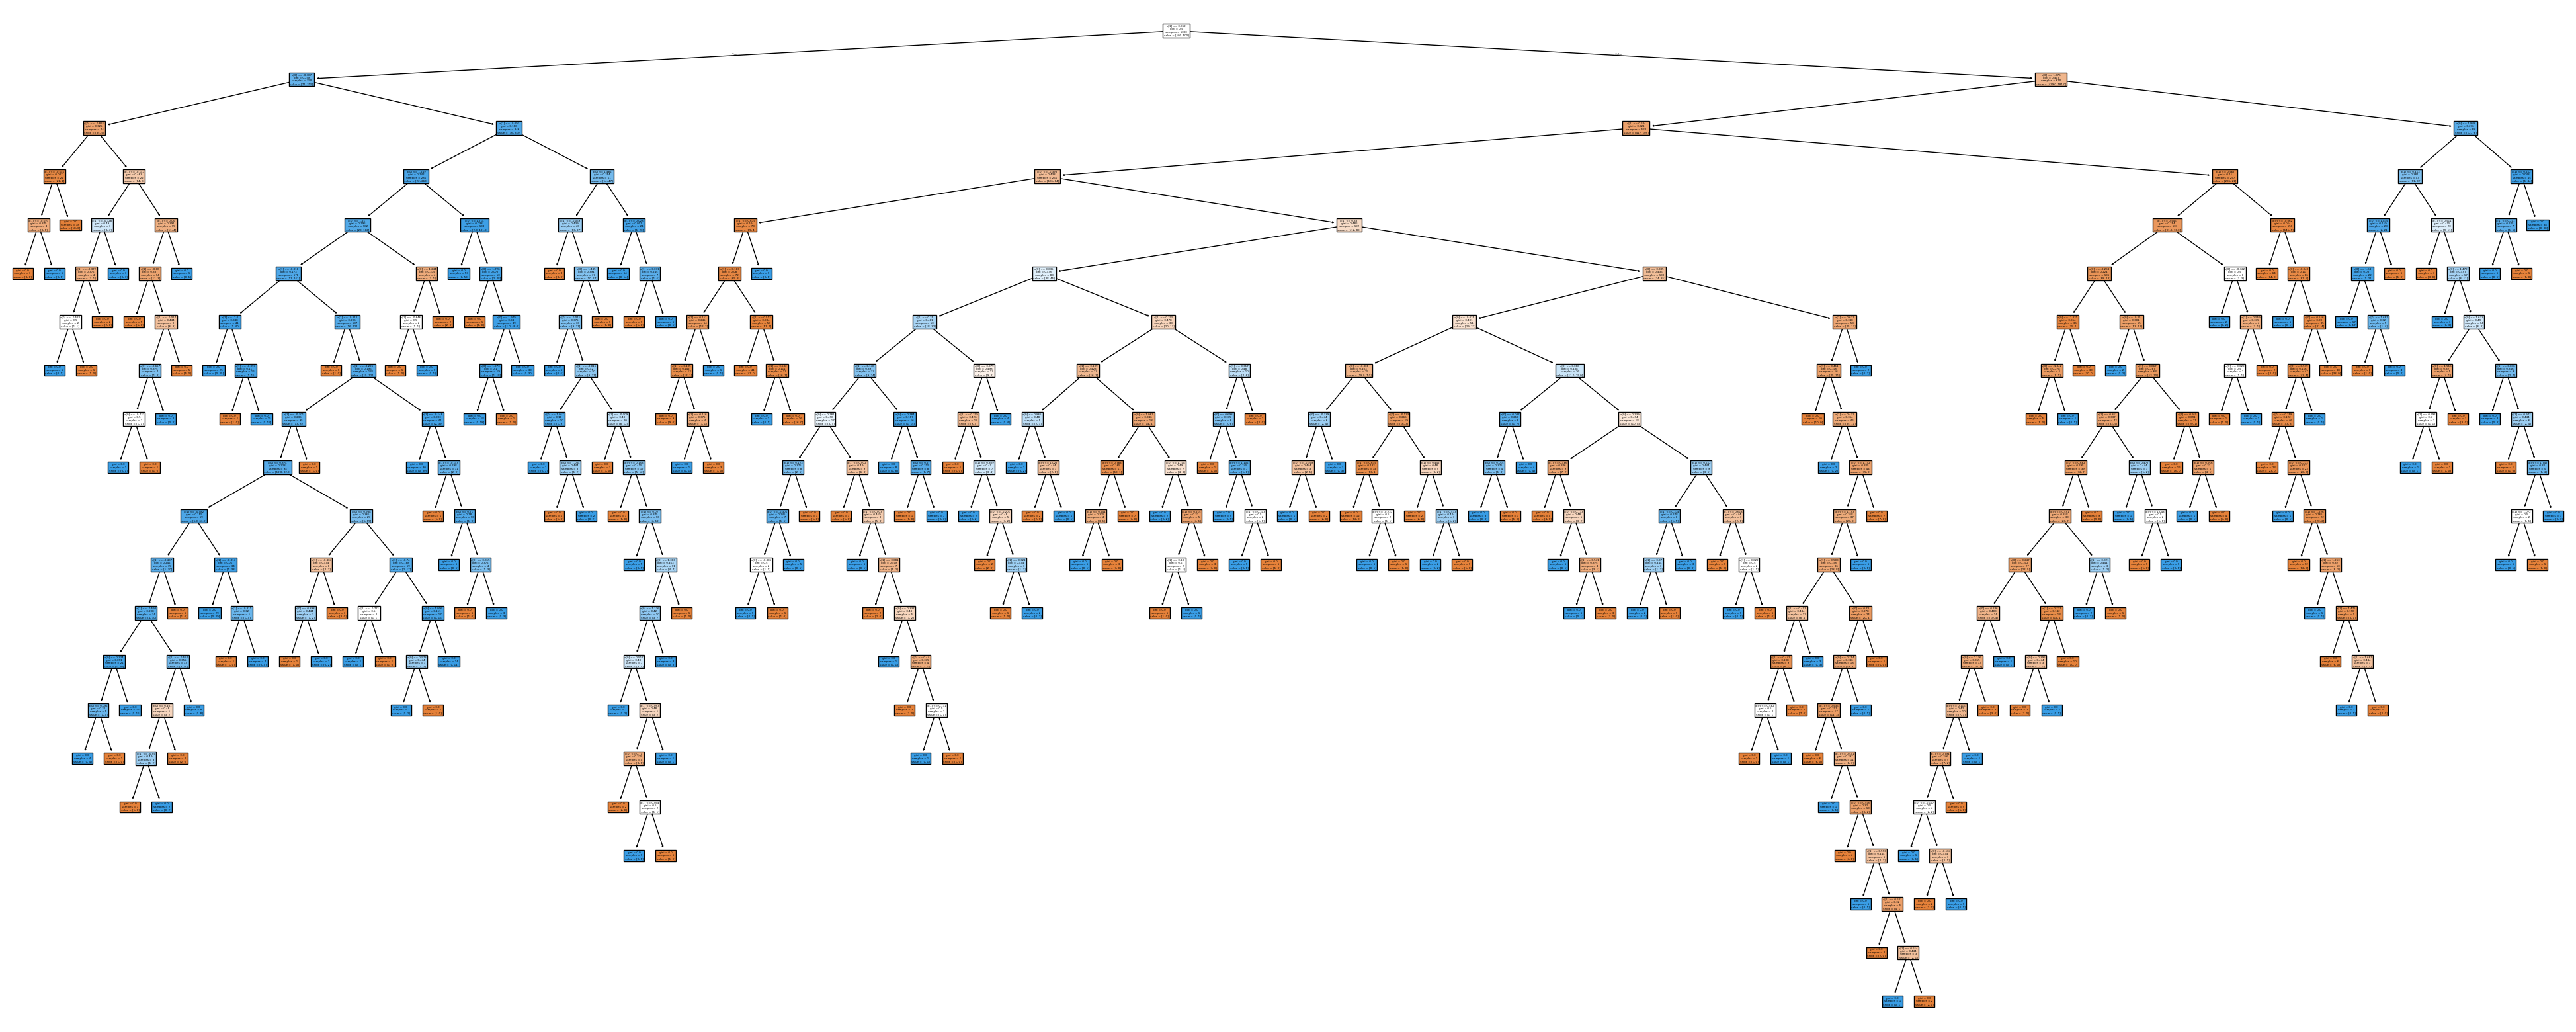

In [49]:
moon_clf = DecisionTreeClassifier(random_state=123)

moon_clf.fit(X,y)

plt.figure(figsize=(50, 20))
plot_tree(moon_clf, filled=True)
plt.show()

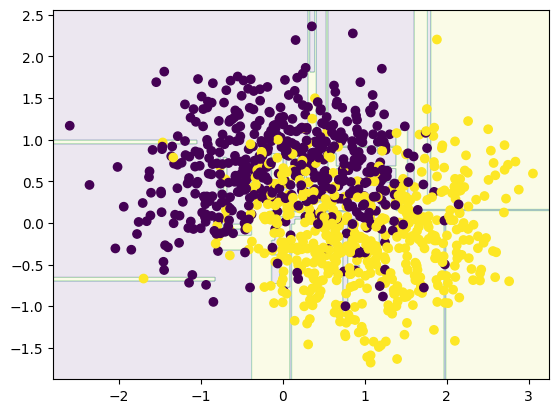

In [55]:
from dibujar_frontera_decision import dibujar_frontera_decision

dibujar_frontera_decision(moon_clf, X, y, X[:,0].min()-0.2, X[:,0].max()+0.2, X[:,1].min()-0.2, X[:,1].max()+0.2)

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

moon_clf = DecisionTreeClassifier(random_state=123)

moon_clf.fit(X_train, y_train)

y_pred = moon_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy, accuracy_score(y_train, moon_clf.predict(X_train))

(0.775, 1.0)

In [71]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=123)

gb_clf.fit(X_train, y_train)

y_pred = gb_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy, accuracy_score(y_train, gb_clf.predict(X_train))

(0.79, 0.975)

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=123)

rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy, accuracy_score(y_train, rf_clf.predict(X_train))

(0.82, 0.86375)